# 1.11 BAL Coupling Calibration: What Is Triggered By State Creation?

A transaction that creates state also consumes execution gas and may access a great deal of existing state. Classifying its whole BAL as state-driven would therefore overstate the state channel. This notebook instead estimates the BAL bytes directly associated with newly created storage slots, accounts, and code.

The retained strict estimate uses the same deterministic 1,200-block sample used to fit the BAL-size regression in notebook 1.3: 10 blocks per day across 120 days. Notebook 2.0 consumes only the compact one-row parameter card written here and remains focused on equilibrium solving.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATE_TAG = "2026-02-01_2026-06-01"
N_BOOTSTRAP = 20_000
RANDOM_SEED = 42

LONG_PANEL_CSV = DATA_DIR / f"calibration_rpc_bal_blocks_{DATE_TAG}.csv"
BLOCK_DATE_CSV = DATA_DIR / f"calibration_bal_block_predictions_{DATE_TAG}.csv"
SAMPLE_PLAN_CSV = DATA_DIR / "calibration_sample_plan_2026-02-01_2026-06-01_n500_seed42.csv"
ATTRIBUTION_BLOCKS_PER_DAY = 10

OUT_BLOCK_CSV = DATA_DIR / f"bal_state_creation_direct_components_{DATE_TAG}.csv"
OUT_DAILY_CSV = DATA_DIR / f"bal_state_creation_direct_daily_{DATE_TAG}.csv"
OUT_DIAGNOSTICS_CSV = DATA_DIR / f"bal_state_creation_coupling_diagnostics_{DATE_TAG}.csv"
OUT_CARD_CSV = DATA_DIR / f"bal_state_creation_coupling_parameter_card_{DATE_TAG}.csv"
OUT_PLOT = PLOTS_DIR / f"bal_state_creation_coupling_calibration_{DATE_TAG}.png"

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

## Exact BAL component bytes

Notebook 1.3 now stores exact RLP byte totals for storage writes, storage reads, balance changes, nonce changes, code changes, and account shells while constructing each BAL. The decomposition therefore uses the same deterministic 1,200 traced blocks as the BAL-size regression and requires no separate component sample, byte-per-unit conversion, regression, or reconciliation.

As an accounting check, the six stored component totals must sum exactly to the observed BAL RLP bytes in every block.

In [2]:
panel = pd.read_csv(LONG_PANEL_CSV)
sample_plan = pd.read_csv(SAMPLE_PLAN_CSV)
attribution_blocks = sample_plan.loc[
    sample_plan["sample_rank"] < ATTRIBUTION_BLOCKS_PER_DAY, ["block_number"]
].drop_duplicates("block_number")
panel = panel.merge(attribution_blocks, on="block_number", how="inner", validate="one_to_one")
if len(panel) != 1_200:
    raise ValueError(f"expected the 1,200 notebook-1.3 calibration blocks, found {len(panel):,}")
block_dates = pd.read_csv(BLOCK_DATE_CSV, usecols=["date", "block_number"]).drop_duplicates("block_number")
panel = panel.merge(block_dates, on="block_number", how="left", validate="one_to_one")
if panel["date"].isna().any():
    raise ValueError("missing dates for some BAL calibration blocks")

component_specs = [
    ("storage_write", "bal_storage_writes_rlp_bytes"),
    ("storage_read", "bal_storage_reads_rlp_bytes"),
    ("balance", "bal_balance_changes_rlp_bytes"),
    ("nonce", "bal_nonce_changes_rlp_bytes"),
    ("code", "bal_code_changes_rlp_bytes"),
    ("account_shell", "bal_account_shell_rlp_bytes"),
]
required_component_columns = [column for _, column in component_specs]
if panel[required_component_columns].isna().any().any():
    raise ValueError("exact BAL component bytes are missing; rerun notebook 1.3 RPC backfill")

panel["observed_bal_bytes"] = panel["bal_rlp_bytes"].astype(float)
for component, source_column in component_specs:
    panel[f"{component}_bytes"] = panel[source_column].astype(float)

component_byte_columns = [f"{component}_bytes" for component, _ in component_specs]
panel["component_bytes_total"] = panel[component_byte_columns].sum(axis=1)
panel["component_reconciliation_error"] = (
    panel["component_bytes_total"] - panel["observed_bal_bytes"]
)
if not np.array_equal(panel["component_bytes_total"].to_numpy(), panel["observed_bal_bytes"].to_numpy()):
    raise ValueError("exact BAL components do not reconcile to observed BAL bytes")

component_summary = pd.DataFrame({
    "component": [component for component, _ in component_specs],
    "rlp_bytes": [panel[f"{component}_bytes"].sum() for component, _ in component_specs],
})
component_summary["share_of_bal_bytes"] = (
    component_summary["rlp_bytes"] / component_summary["rlp_bytes"].sum()
)
display(component_summary)
print(f"maximum component reconciliation error: {panel['component_reconciliation_error'].abs().max():,.0f} bytes")

,component,rlp_bytes,share_of_bal_bytes
0,storage_write,"72,558,506.000000",0.450943
1,storage_read,"43,196,287.000000",0.268460
2,balance,"13,196,361.000000",0.082014
3,nonce,"2,391,626.000000",0.014864
4,code,"3,602,318.000000",0.022388
5,account_shell,"25,958,744.000000",0.161331


maximum component reconciliation error: 0 bytes


## Direct state-creation-linked entries

The strict proxy assigns only three kinds of BAL content to the state-creation channel:

- the storage-write entry for a newly created storage slot;
- the account shell for a newly created account; and
- new contract code or delegation-indicator bytes recorded as a code change.

Storage reads, writes to existing slots, balance changes, and nonce changes stay with execution/state-access activity. We do not proportionally reassign ambiguous balance or nonce bytes to state creation. Within each block, exact storage-write, account-shell, and code-component bytes are allocated according to the directly matched share of new units in that component. The remaining approximation is this within-component allocation of RLP framing, not a conversion learned from another sample.

In [3]:
panel["linked_new_storage_slots"] = np.minimum(panel["rpc_new_storage_slots"], panel["bal_storage_write_slots"])
panel["linked_new_accounts"] = np.minimum(panel["rpc_new_accounts"], panel["bal_accounts"])
panel["candidate_new_code_bytes"] = panel["rpc_code_bytes"] + 23 * panel["rpc_new_delegation_indicators"]
panel["linked_new_code_bytes"] = np.minimum(panel["candidate_new_code_bytes"], panel["bal_code_bytes"])


def safe_fraction(numerator: pd.Series, denominator: pd.Series) -> np.ndarray:
    numerator_values = numerator.to_numpy(dtype=float)
    denominator_values = denominator.to_numpy(dtype=float)
    return np.divide(
        numerator_values, denominator_values,
        out=np.zeros_like(numerator_values), where=denominator_values > 0,
    )

panel["state_linked_storage_bytes"] = panel["storage_write_bytes"] * safe_fraction(
    panel["linked_new_storage_slots"], panel["bal_storage_write_slots"]
)
panel["state_linked_shell_bytes"] = panel["account_shell_bytes"] * safe_fraction(
    panel["linked_new_accounts"], panel["bal_accounts"]
)
panel["state_linked_code_bytes"] = panel["code_bytes"] * safe_fraction(
    panel["linked_new_code_bytes"], panel["bal_code_bytes"]
)
panel["state_linked_bytes_strict"] = panel[[
    "state_linked_storage_bytes", "state_linked_shell_bytes", "state_linked_code_bytes"
]].sum(axis=1)

STRICT_STATE_WEIGHT = panel["state_linked_bytes_strict"].sum() / panel["observed_bal_bytes"].sum()
panel["state_linked_share_strict"] = panel["state_linked_bytes_strict"] / panel["observed_bal_bytes"]
panel.to_csv(OUT_BLOCK_CSV, index=False)

print(f"strict direct-entry share: {STRICT_STATE_WEIGHT:.3%}")

strict direct-entry share: 13.268%


In [4]:
daily = panel.groupby("date", as_index=False).agg(
    sampled_blocks=("block_number", "size"),
    observed_bal_bytes=("observed_bal_bytes", "sum"),
    state_linked_bytes_strict=("state_linked_bytes_strict", "sum"),
)
daily["state_linked_share_strict"] = daily["state_linked_bytes_strict"] / daily["observed_bal_bytes"]
daily.to_csv(OUT_DAILY_CSV, index=False)

daily_values = daily[["observed_bal_bytes", "state_linked_bytes_strict"]].to_numpy(dtype=float)
rng = np.random.default_rng(RANDOM_SEED)
draws = rng.integers(0, len(daily_values), size=(N_BOOTSTRAP, len(daily_values)))
boot = daily_values[draws].sum(axis=1)
boot_strict = boot[:, 1] / boot[:, 0]

parameter_card = pd.DataFrame([{
    "role": "strict_direct_entries",
    "state_creation_weight": STRICT_STATE_WEIGHT,
    "execution_state_access_weight": 1 - STRICT_STATE_WEIGHT,
    "bootstrap_ci_2_5": np.quantile(boot_strict, 0.025),
    "bootstrap_ci_97_5": np.quantile(boot_strict, 0.975),
    "definition": "new storage-slot writes + new-account shells + new code",
    "sample_blocks": len(panel),
    "sample_days": daily["date"].nunique(),
    "sample_period": DATE_TAG,
    "bal_data_price_elasticity": 0.0,
}])
parameter_card.to_csv(OUT_CARD_CSV, index=False)

diagnostics = pd.DataFrame([{
    "exact_component_blocks": len(panel),
    "exact_component_days": daily["date"].nunique(),
    "component_reconciliation_max_abs_bytes": panel["component_reconciliation_error"].abs().max(),
    "component_reconciliation_total_abs_bytes": panel["component_reconciliation_error"].abs().sum(),
    "new_storage_slots_share_of_bal_write_slots": panel["linked_new_storage_slots"].sum() / panel["bal_storage_write_slots"].sum(),
    "new_accounts_share_of_bal_accounts": panel["linked_new_accounts"].sum() / panel["bal_accounts"].sum(),
    "new_code_share_of_bal_code_bytes": panel["linked_new_code_bytes"].sum() / panel["bal_code_bytes"].sum(),
    "strict_state_linked_bal_share": STRICT_STATE_WEIGHT,
}])
diagnostics.to_csv(OUT_DIAGNOSTICS_CSV, index=False)
display(parameter_card)
display(diagnostics.T)

,role,state_creation_weight,execution_state_access_weight,bootstrap_ci_2_5,bootstrap_ci_97_5,definition,sample_blocks,sample_days,sample_period,bal_data_price_elasticity
0,strict_direct_entries,0.132676,0.867324,0.124803,0.141094,new storage-slot writes + new-account shells +...,1200,120,2026-02-01_2026-06-01,0.000000


,0
exact_component_blocks,"1,200.000000"
exact_component_days,120.000000
component_reconciliation_max_abs_bytes,0.000000
component_reconciliation_total_abs_bytes,0.000000
new_storage_slots_share_of_bal_write_slots,0.228289
new_accounts_share_of_bal_accounts,0.051831
new_code_share_of_bal_code_bytes,0.992605
strict_state_linked_bal_share,0.132676


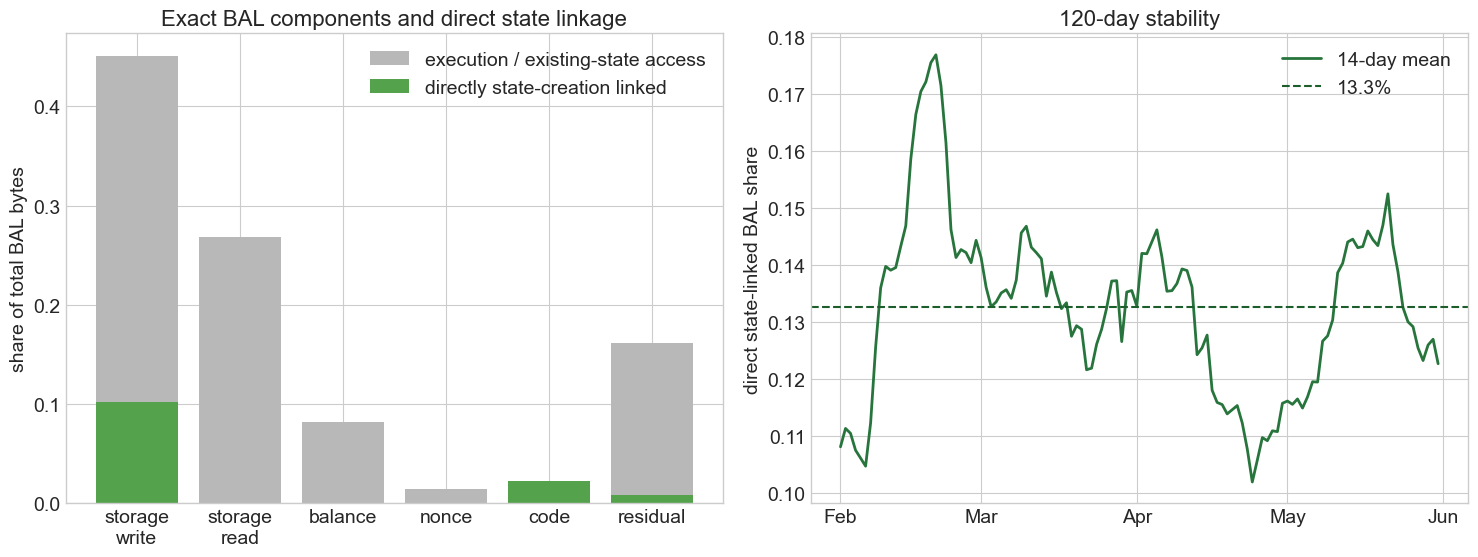

In [5]:
component_names = [component for component, _ in component_specs]
component_totals = np.array([panel[f"{name}_bytes"].sum() for name in component_names])
linked_component_totals = np.array([
    panel["state_linked_storage_bytes"].sum(), 0.0, 0.0, 0.0,
    panel["state_linked_code_bytes"].sum(), panel["state_linked_shell_bytes"].sum(),
])
component_shares = component_totals / component_totals.sum()
linked_shares = linked_component_totals / component_totals.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
ax = axes[0]
x = np.arange(len(component_names))
ax.bar(x, component_shares - linked_shares, bottom=linked_shares, color="#B8B8B8", label="execution / existing-state access")
ax.bar(x, linked_shares, color="#54A24B", label="directly state-creation linked")
ax.set_xticks(x, ["storage\nwrite", "storage\nread", "balance", "nonce", "code", "residual"])
ax.set_ylabel("share of total BAL bytes", fontsize=14)
ax.tick_params(axis="both", labelsize=14)
ax.set_title("Exact BAL components and direct state linkage", fontsize=16)
ax.legend(fontsize=14)

daily_plot = daily.copy()
daily_plot["date"] = pd.to_datetime(daily_plot["date"])
daily_plot = daily_plot.sort_values("date")
ax = axes[1]
strict_rolling = daily_plot["state_linked_share_strict"].rolling(14, center=True, min_periods=7).mean()
ax.plot(daily_plot["date"], strict_rolling, color="#27753C", linewidth=2, label="14-day mean")
ax.axhline(STRICT_STATE_WEIGHT, color="#1B5E2B", linestyle="--", label=f"{STRICT_STATE_WEIGHT:.1%}")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_ylabel("direct state-linked BAL share", fontsize=14)
ax.tick_params(axis="both", labelsize=14)
ax.set_title("120-day stability", fontsize=16)
ax.legend(fontsize=14)

fig.tight_layout()
fig.savefig(OUT_PLOT, dpi=160, bbox_inches="tight")
plt.show()

## Parameter passed to notebook 2.0

The reduced-form BAL quantity becomes

$$B_t=B_0\left[(1-w_S)\frac{A_t}{A_0}+w_S\frac{S_t}{S_0}\right]\left(\frac{p_{D,t}}{p_{D,0}}\right)^{-\gamma_{\mathrm{BAL}}},$$

where $A_t$ is execution/state-access activity, $S_t$ is persistent state creation, and $w_S$ is only the direct-entry share estimated here. In notebook 2.0, total execution quantity remains the available reduced-form proxy for $A_t$.

This distinction matters. State-creating transactions generate many BAL entries, but ordinary reads and accesses to existing state should not inherit the state-creation quantity. The strict estimate assigns 13.3% of BAL bytes to newly created storage entries, account shells, and code; the remaining 86.7% stays attached to execution/state-access activity. The remaining limitation is that total execution gas is an imperfect proxy for state access; a later transaction-bundle model should replace it with an explicit access index.

In [6]:
assert len(panel) == 1_200
assert panel["component_reconciliation_error"].eq(0).all()
assert 0 < STRICT_STATE_WEIGHT < 1
assert np.isclose(STRICT_STATE_WEIGHT, 0.13267612258149933)
assert len(parameter_card) == 1
assert np.isclose(parameter_card["state_creation_weight"] + parameter_card["execution_state_access_weight"], 1).all()
print(OUT_CARD_CSV)
print(OUT_PLOT)

/Users/william/PycharmProjects/eip-7999-research/data/bal_state_creation_coupling_parameter_card_2026-02-01_2026-06-01.csv
/Users/william/PycharmProjects/eip-7999-research/plots/bal_state_creation_coupling_calibration_2026-02-01_2026-06-01.png
